### Projet Complet avec la librairie TensorFlow

### Prétraitement et exploration des données

Dans cette sous-section, nous effectuerons les opérations relatives au prétraitement des données, puis nous passerons à la phase exploratoire afin de mieux comprendre les données à notre disposition. 
Dans le bout de codes ci-dessous, nous chargeons notre dataset et examinons les formats des bases d’apprentissage et de test.

In [2]:
# Importation des librairies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
# Chargement des donnees
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print('Train set X:', X_train.shape)
print('Test set X:', X_test.shape)
print('Train set y:', y_train.shape)
print('Test set y:', y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 16s 1us/step
Train set X: (60000, 28, 28)
Test set X: (10000, 28, 28)
Train set y: (60000,)
Test set y: (10000,)


À la lumière des resultat ci haut, on constate que les caractéristiques des données sont dans un format à trois dimensions (le nombre d’images, les pixels en largeur et les pixels en hauteur). 
Ce type de format des données est couramment rencontré dans des tâches de computer vision, un des principaux domaines d’application du Deep Learning qui est le sujet du chapitre suivant. 
Dans la modélisation, nous allons procéder à l’aplatissement des pixels pour chaque image afin de retrouver le format classique à deux dimensions. 
Bien avant, nous représentons graphiquement un échantillon des données de notre dataset dans la Figure suivante.

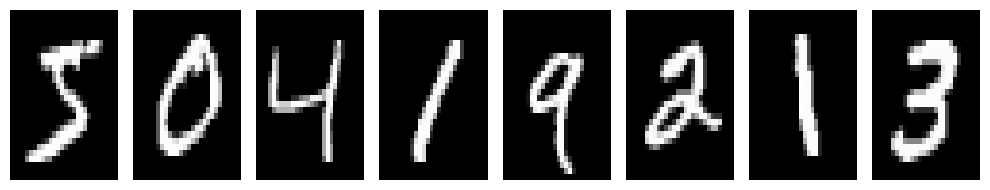

In [5]:
# Visualiation des donnees
fig, axes = plt.subplots(nrows = 1, ncols = 8, figsize = (10, 2))
for i, ax in enumerate(axes.flatten()):
    sns.heatmap(data=X_train[i], ax=ax, cmap ='gray', cbar=False)
    ax.axis('off')

plt.tight_layout()

Les pixels des images varient dans une plage allant de 0 à 255. 
Cela implique que, pour certaines images, les valeurs des pixels peuvent être proches de 0 (couleur noire), et pour d’autres, elles peuvent être proches de 255 (couleur blanche). 
En d’autres termes, les données ne sont pas sur la même échelle. 
Sachant que les réseaux de neurones sont des modèles sensibles au feature scaling, il est crucial de procéder à la standardisation des données avant la phase de modélisation. 
La technique qui sera utilisée ici est celle du “Min-Max Scaler” qui consiste à placer les données dans une échelle variant entre 0 et 1. 
Cette opération de prétraitement devrait permettre d’améliorer la convergence de l’algorithme d’optimisation des paramètres du modèle.

In [6]:
# Reformatage et standardisation des donnees
from sklearn.preprocessing import MinMaxScaler
X_train_new = X_train.reshape(X_train.shape[0], -1)
X_test_new = X_test.reshape(X_test.shape[0], -1)
X_train = MinMaxScaler().fit(X_train_new).transform(X_train_new)
X_test = MinMaxScaler().fit(X_test_new).transform(X_test_new)

print('Train set:', X_train.shape)
print('Test set:', X_test.shape)

Train set: (60000, 784)
Test set: (10000, 784)


Le resultat renseigne les formats des données standardisées. À l’issue de la mise à l’échelle des données, les caractéristiques ont été placées dans un format à deux dimensions. 
L’opération a consisté à aplatir les pixels de chaque image de sorte à les ranger dans un vecteur unidimensionnel. Ce qui nous a permis d’obtenir un total de 784 (28x28) caractéristiques par image.

Un autre élément pour lequel il faut se rassurer avant de passer à la phase de modélisation, c’est la distribution des classes dans la base d’apprentissage. 
Ceci nous permet de vérifier si il y existe des classes sur-représentées ou sous-représentées. 
Si les classes sont inéquitablement réparties, on dit alors qu’il existe un “déséquilibre dans les données” (imbalanced data). 
Pour le cas de notre dataset, la distribution des données semble équitable entre les classes (cf. Figure suivante). Il n’est donc pas utile de recourir ici aux techniques de ré-échantillonnage devant conduire à résoudre un problème potentiel de déséquilibre des classes à prédire.

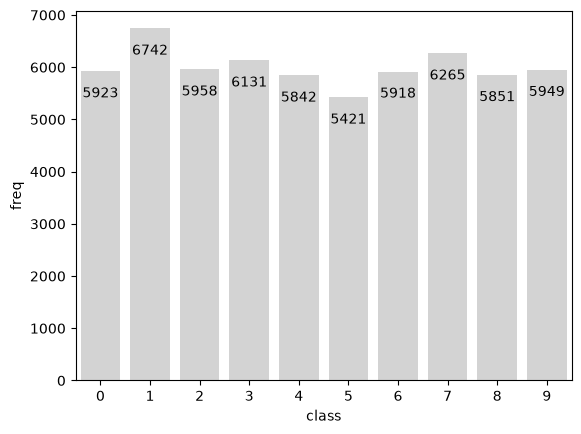

In [7]:
# Equilibre dans les donnees
classes = np.unique(y_train, return_counts=True)
classes = pd.DataFrame({'class': classes[0], 'freq': classes[1]})

bar_plot=sns.barplot(data=classes, x='class', y='freq', color='lightgray')
for i in range(len(classes['class'])):
    bar_plot.text(i, classes.iloc[i]['freq'] - 500, classes.iloc[i]['freq'], ha = 'center')

Avant de passer à la construction du modèle, nous allons également reformater le vecteur de la variable cible. 
Il s’agit d’une variable catégorielle dont les modalités sont les 10 classes à prédire. 
Ce reformatage sera effectué par encodage catégoriel des étiquettes de la variable cible en vecteurs one-hot. 
Les vecteurs one-hot sont des vecteurs de longueur égale au nombre de modalités de la variable cible. 
Chaque entrée du vecteur est égale à 0, sauf l’entrée correspondant à la catégorie de l’étiquette, qui est égale à 1. Cet encodage est nécessaire pour la plupart des modèles de Deep Learning, car il permet de prendre en compte le fait que les différentes classes à prédire sont mutuellement exclusives.

In [8]:
# Encodage categoriel des etiquettes en vecteurs one-hot
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print('Train set:', y_train.shape)
print('Test set:', y_test.shape)

Train set: (60000, 10)
Test set: (10000, 10)


## Construction, entraînement et évaluation du modèle

Le phase de prétraitement étant achevée, cette sous-section aborde la phase de modélisation proprement dite. 
La construction du modèle sera réalisée au moyen de la fonction Sequential() qui permet de créer les couches du réseau l’une après l’autre. 
La première couche comporte 128 neurones, la deuxième 64 neurones, et la troisième 32 neurones. 
Ces trois premières couches sont dotées d’une fonction d’activation du type “ReLU”. La fonction Rectified Linear Unit (ReLU) est une fonction d’activation non-linéaire couramment utilisée dans les réseaux de neurones artificiels. 
Elle présente l’avantage de favoriser la sparsité des poids d’un réseau de neurones. Ce phénomène de sparsité se produit lorsque de nombreux poids dans le réseau sont proches de zéro. 
La fonction ReLU permet ainsi de réduire le nombre de paramètres à optimiser, ce qui peut accélérer l’apprentissage du modèle. C’est cet avantage qui fait de la ReLU une fonction idéale pour les premières couches du réseau à entraîner.

La dernière couche comporte 10 neurones, en référence aux 10 classes à prédire. Elle est dotée d’une fonction d’activation du type “soft-max”. 
Au moins trois raisons conduisent les data scientists à utiliser cette fonction d’activation pour la dernière couche d’un réseau de neurones. 

(i) La fonction soft-max est différentiable, tout comme la fonction logistique. Cette propriété est nécessaire pour l’entraînement des réseaux de neurones par la backward propagation. 

(ii) Tout comme la fonction logistique, la fonction soft-max produit des sorties sous forme de probabilités. Seulement, la fonction soft-max est plus adaptée aux problèmes de classification multi-classes. 

(iii) Contrairement à la fonction logistique, la fonction soft-max est compatible avec l’entropie croisée comme fonction-coût.

Notre modèle est configuré en considérant l’entropie croisée comme mesure permettant de quantifier les erreurs de prédiction. L’entropie croisée est un indicateur de la similarité entre deux distributions de probabilité. Minimiser cette fonction-coût revient donc à réduire la différence entre la
distribution des prédictions du modèle et la distribution des données réelles. 
Elle est préférée à la
fonction-coût log loss développée dans les sections 2 et 3 en ce sens qu’elle pénalise fortement les 5
prédictions qui sont confiantes, mais incorrectes. De plus, l’entropie croisée est compatible avec la fonction d’activation soft-max, laquelle est souvent utilisée dans la dernière couche d’un réseau de neurones pour transformer les valeurs agrégées en probabilités. 
Enfin, l’algorithme d’optimisation spécifié pour la configuration du modèle est la descente de gradient stochastique, et la métrique de précision utilisée est l’Accuracy. 
L’architecture du modèle configuré est présentée dans la Figure suivante

In [23]:
# Construction du modele
model = Sequential()
model.add(Dense(units=128, activation='relu', input_dim=len(X_train[1])))

model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

# Configuration et Resume du modele
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary(show_trainable = True)

# Graphique du modele
"""
!pip install pydot
!pip install graphviz
import os
os.environ['PATH'] += os.pathsep
"""
from tensorflow.keras.utils import plot_model
plot_model(model, to_file = 'ModelGraph.png', show_shapes = True, show_layer_activations = True)

""" INSTRUCTIONS SUPPLEMENTAIRES
Pour afficher le graphique du modele, vous devez:
(i) telecharger GRAPHVIZ : https://graphviz.gitlab.io/download/
(ii) ajouter le chemin vers son executable a l'environnement PATH
"""

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ dense_28 (Dense)            │ (None, 128)           │    100,480 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_29 (Dense)            │ (None, 64)            │      8,256 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_30 (Dense)            │ (None, 32)            │      2,080 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_31 (Dense)            │ (None, 10)            │        330 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


" INSTRUCTIONS SUPPLEMENTAIRES\nPour afficher le graphique du modele, vous devez:\n(i) telecharger GRAPHVIZ : https://graphviz.gitlab.io/download/\n(ii) ajouter le chemin vers son executable a l'environnement PATH\n"

Une fois le modèle construit et configuré, il peut être entraîné sur la base d’apprentissage. 
Pour des raisons de comparaison, nous allons retenir le même nombre d’itérations qu’au modèle entraîné dans la section précédente avec la librairie scikit-learn. 
Le but ici sera d’apprécier le gain en termes de temps de traitement qu’offre la librairie TensorFlow. 
Enfin, nous conserverons 25% des données d’entraînement pour l’évaluation des métriques (perte et précision) par itération en guise de validation croisée.

In [24]:
# Entrainement du model sur la base d'apprentisage
NN_model = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=.25)

# Evaluation du modele sur la base d'apprentissage
train_loss, train_acc = model.evaluate(X_train, y_train)
print('Train accuracy:', train_acc)

# Evaluation du modele sur la base de test
test_loss, test_acc = model.evaluate(X_test, y_test)

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9135 - loss: 0.2891 - val_accuracy: 0.9511 - val_loss: 0.1714
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step - accuracy: 0.9640 - loss: 0.1182 - val_accuracy: 0.9625 - val_loss: 0.1266
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.9743 - loss: 0.0835 - val_accuracy: 0.9632 - val_loss: 0.1297
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 982us/step - accuracy: 0.9802 - loss: 0.0619 - val_accuracy: 0.9674 - val_loss: 0.1095
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.9855 - loss: 0.0461 - val_accuracy: 0.9687 - val_loss: 0.1141
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9881 - loss: 0.0384 - val_accuracy: 0.9683 - val_loss: 0.1198
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - accuracy: 0.9888 - loss: 0.0355 - val_accuracy: 0.9707 - val_loss: 0.1102
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 997us/step - accuracy: 0.99

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.9754 - val_loss: 0.2018
Epoch 51/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 985us/step - accuracy: 0.9989 - loss: 0.0045 - val_accuracy: 0.9739 - val_loss: 0.2115
Epoch 52/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - accuracy: 0.9980 - loss: 0.0070 - val_accuracy: 0.9693 - val_loss: 0.2589
Epoch 53/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 986us/step - accuracy: 0.9982 - loss: 0.0058 - val_accuracy: 0.9721 - val_loss: 0.2493
Epoch 54/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 996us/step - accuracy: 0.9980 - loss: 0.0097 - val_accuracy: 0.9757 - val_loss: 0.2120
Epoch 55/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 993us/step - accuracy: 0.9986 - loss: 0.0049 - val_accuracy: 0.9741 - val_loss: 0.2164
Epoch 56/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 991us/step - accuracy: 0.9987 - loss: 0.0050 - val_accuracy: 0.9752 - val_loss: 0.2153
Epoch 57/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9990 - 

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9990 - loss: 0.0045 - val_accuracy: 0.9767 - val_loss: 0.2495
Epoch 100/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 1s 985us/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9753 - val_loss: 0.2746
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 373us/step - accuracy: 0.9930 - loss: 0.0714
Train accuracy: 0.9930166602134705
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step - accuracy: 0.9786 - loss: 0.2301
Test accuracy: 0.978600025177002


Avec la librairie TensorFlow, il n’est pas nécessaire de programmer une barre de progression pour suivre le temps requis pour entrainer le modèle. En effet, la méthode fit() produit déjà le temps d’exécution du code à travers les itérations durant l’entraînement du modèle. 
Les résultats indiquent qu’il a fallu en moyenne 4.68 secondes par itération pour entraîner complètement le modèle, ce qui correspond à une durée totale de traitement de 7 minutes et 48.7 secondes ! Il s’agit là d’un énorme gain en temps, d’autant plus que le modèle entraîıné dans cette section comporte plus de couches masquées que celui entraîné dans la section précédente. 
Les performances du modèle dans les bases d’apprentissage et de test sont renseignées dans le Tableau suivant

In [25]:
print('Test accuracy:', test_acc)

Test accuracy: 0.978600025177002


Text(0.5, 1.0, '(b) Courbe de Precision')

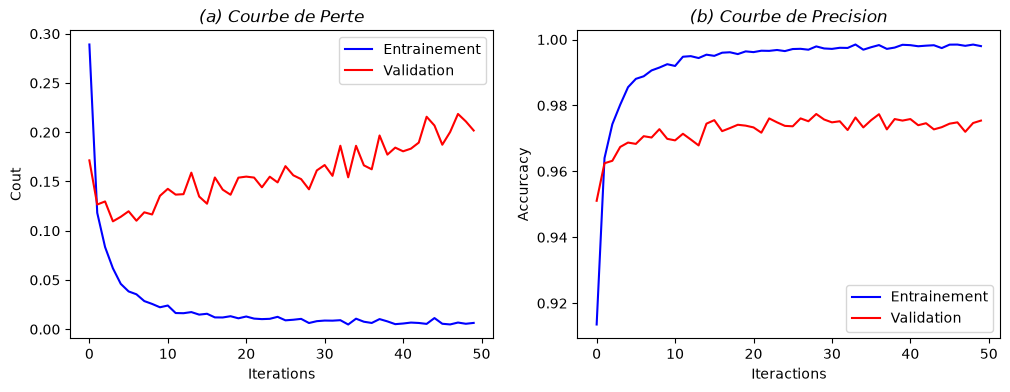

In [29]:
# Courbes de perte et de precision
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
sns.lineplot(data = NN_model.history['loss'][:50], label = 'Entrainement', color = 'blue')
sns.lineplot(data = NN_model.history['val_loss'][:50], label = 'Validation', color = 'red')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Cout')
plt.title('(a) Courbe de Perte', fontstyle = 'oblique')

plt.subplot(1, 2, 2)
sns.lineplot(data = NN_model.history['accuracy'][:50], label = 'Entrainement', color = 'blue')
sns.lineplot(data = NN_model.history['val_accuracy'][:50], label = 'Validation', color = 'red')

plt.legend()
plt.xlabel('Iteractions')
plt.ylabel('Accurcacy')
plt.title('(b) Courbe de Precision', fontstyle = 'oblique')